# Experiment: Downstream Loss Curves by Initialization

This notebook compares downstream validation-loss curves for initialization choices:
- `random`
- basis-derived inits (`chebyshev`, `fourier`, `rbf`, `poly_exp`)

Each curve comes from fine-tuning on WikiText-2 and evaluating every `N` steps.


In [8]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 120


def find_repo_root(start: Path | None = None) -> Path:
    cur = (start or Path.cwd()).resolve()
    for candidate in [cur, *cur.parents]:
        if (candidate / 'pyproject.toml').exists():
            return candidate
    raise FileNotFoundError('Could not locate repo root')

ROOT = find_repo_root()
CURVES_PATH = ROOT / 'artifacts' / 'demo_basis_sweep' / 'init_eval_basis_curves.json'

payload = json.loads(CURVES_PATH.read_text(encoding='utf-8'))
results = payload['results']

print('ROOT:', ROOT)
print('Curves file:', CURVES_PATH)
print('init_mode:', payload.get('init_mode'))
print('train_steps:', payload.get('train_steps'))
print('eval_every:', payload.get('eval_every'))
print('labels:', [r['label'] for r in results])


ROOT: /Users/jacksonpetty/Development/platonic-init
Curves file: /Users/jacksonpetty/Development/platonic-init/artifacts/demo_basis_sweep/init_eval_basis_curves.json
init_mode: sampled
train_steps: 200
eval_every: 10
labels: ['random', 'chebyshev', 'fourier', 'rbf', 'poly_exp']


## Summary Table


In [9]:
summary_rows = []
for r in results:
    summary_rows.append({
        'init': r['label'],
        'initial_eval_loss': r.get('initial_eval_loss'),
        'best_eval_loss': r.get('best_eval_loss'),
        'final_eval_loss': r.get('final_eval_loss', r.get('eval_loss')),
    })

summary_df = pd.DataFrame(summary_rows).sort_values('init').reset_index(drop=True)
summary_df


,init,initial_eval_loss,best_eval_loss,final_eval_loss
0,chebyshev,10.576910,10.505136,10.505136
1,fourier,10.578641,10.515164,10.515164
2,poly_exp,10.581213,10.512815,10.512815
3,random,10.576051,10.500371,10.500371
4,rbf,10.576816,10.504971,10.504971


## Plot: Validation-Loss Curves by Init


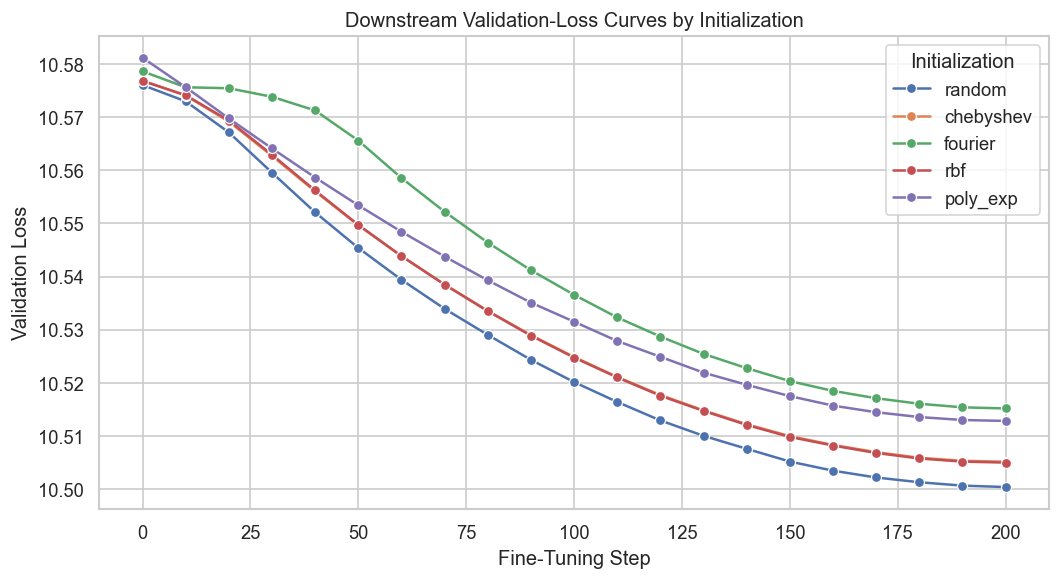

In [10]:
curve_rows = []
for r in results:
    label = r['label']
    for point in r.get('eval_curve', []):
        curve_rows.append({
            'init': label,
            'step': int(point['step']),
            'eval_loss': float(point['eval_loss']),
        })

curve_df = pd.DataFrame(curve_rows).sort_values(['init', 'step']).reset_index(drop=True)

preferred_order = ['random', 'chebyshev', 'fourier', 'rbf', 'poly_exp']
available = [x for x in preferred_order if x in curve_df['init'].unique()]
remaining = sorted([x for x in curve_df['init'].unique() if x not in available])
hue_order = available + remaining

plt.figure(figsize=(9, 5))
sns.lineplot(
    data=curve_df,
    x='step',
    y='eval_loss',
    hue='init',
    hue_order=hue_order,
    marker='o',
)
plt.title('Downstream Validation-Loss Curves by Initialization')
plt.xlabel('Fine-Tuning Step')
plt.ylabel('Validation Loss')
plt.legend(title='Initialization', loc='best')
plt.tight_layout()
plt.show()
